# Stream Modeling with streamdf

galpy's `streamdf` class models tidal streams using action-angle coordinates.
The basic idea is that stream stars were stripped from a progenitor at different
times and therefore have slightly different orbital frequencies. Over time, this
frequency spread causes them to spread out along the orbit, forming a stream.
`streamdf` predicts the stream track on the sky, the density along the stream,
and allows sampling of stream stars.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.df import streamdf
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.actionAngle import actionAngleIsochroneApprox
from galpy.util import conversion

## Setup

We need three ingredients to initialize a `streamdf` instance:

1. A gravitational potential
2. An action-angle calculator for that potential
3. A progenitor orbit

In [2]:
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
aAIA = actionAngleIsochroneApprox(pot=lp, b=0.8)
obs = Orbit([1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596])

## Initialize streamdf

Now we initialize the `streamdf` model. The key parameters are:

- `sigv`: the velocity dispersion of the progenitor (in natural units)
- `progenitor`: the progenitor orbit
- `pot`: the gravitational potential
- `aA`: the action-angle instance
- `leading`: whether to model the leading (`True`) or trailing (`False`) arm
- `tdisrupt`: the time since disruption began (in natural units)

In [3]:
sigv = 0.365  # km/s
sdf = streamdf(
    sigv / 220.0,
    progenitor=obs,
    pot=lp,
    aA=aAIA,
    leading=True,
    nTrackChunks=11,
    tdisrupt=4.5 / conversion.time_in_Gyr(220.0, 8.0),
)

## Plot the stream track

We can visualize the predicted stream track and the progenitor's orbit.

Text(0, 0.5, '$Z$')

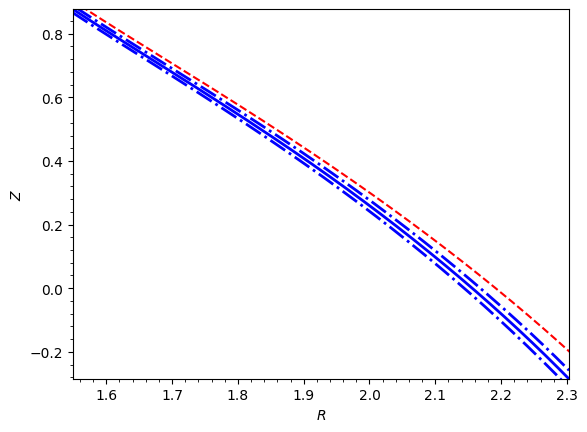

In [4]:
sdf.plotTrack(d1="r", d2="z", interp=True, color="b", spread=2, overplot=False, lw=2.0)
sdf.plotProgenitor(d1="r", d2="z", color="r", overplot=True, ls="--")
plt.xlabel(r"$R$")
plt.ylabel(r"$Z$")

## Stream length and width

We can compute the stream length (the angular extent along the stream)
and the width (the spread perpendicular to the stream track).

In [5]:
print("Stream length (radians):", sdf.length(ang=True))
print("Stream length (physical):", sdf.length(phys=True))

Stream length (radians): 93.48282256049195
Stream length (physical): 12.31150295587134


## Sample from the stream

We can draw random samples of stars from the stream distribution function.

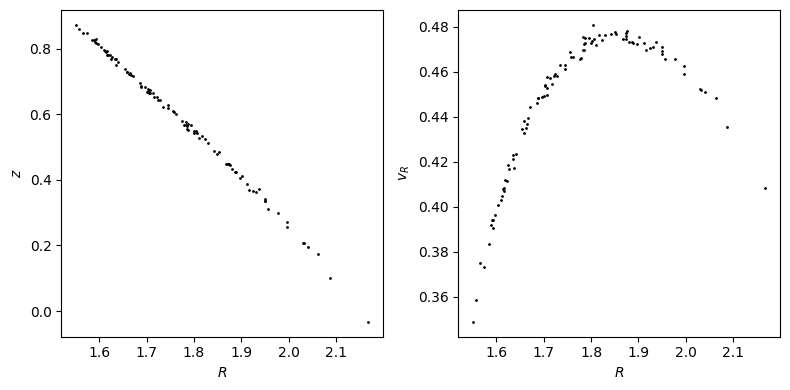

In [6]:
RvR = sdf.sample(n=100)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(RvR[0], RvR[3], "k.", ms=2)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.subplot(1, 2, 2)
plt.plot(RvR[0], RvR[1], "k.", ms=2)
plt.xlabel(r"$R$")
plt.ylabel(r"$v_R$")
plt.tight_layout()

## Predict observables with callMarg

`streamdf` can also compute marginalized predictions for observables.
For example, the predicted distribution of distance at a given angle
along the stream, marginalizing over all other phase-space dimensions.
Dimensions set to `None` are marginalized over.

/home/bovy/Repos/galpy/galpy/df/streamdf.py:3024: RuntimeWarning: divide by zero encountered in log
  loga = numpy.log(



Text(0, 0.5, '$p(X)$')

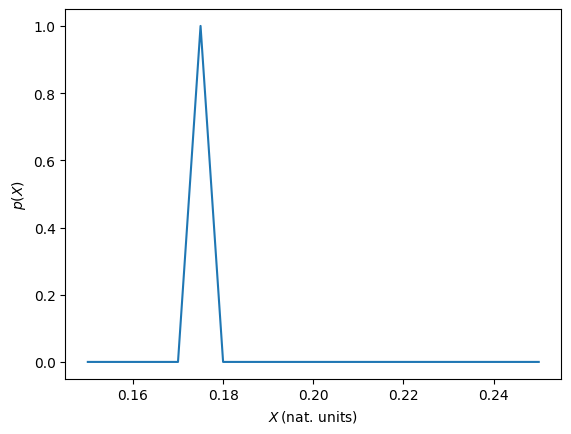

In [7]:
xs = numpy.linspace(0.15, 0.25, 21)
logp = numpy.array([sdf.callMarg([x, None, 2.0 / 8.0, None, None, None]) for x in xs])
plt.plot(xs, numpy.exp(logp - numpy.nanmax(logp)))
plt.xlabel(r"$X\,(\mathrm{nat.\,units})$")
plt.ylabel(r"$p(X)$")